# Table of contents

1. [Configuration](#Configuration)
2. [Load datasets](#Load-datasets)
3. [Dimensionality reduction](#Dimensionality-reduction)
   - [PCA](#PCA)
   - [KPCA](#KPCA)
   - [LLE](#LLE)
   - [Laplacian Eigenmaps](#Laplacian-Eigenmaps)
   - [t-SNE](#t-SNE)
   - [UMAP](#UMAP)
4. [Bảng nhận xét tổng hợp](#Bảng-nhận-xét-tổng-hợp)


# Configuration

In [1]:
import sys
from pathlib import Path

# Resolve lab root so the notebook runs from different working directories.
def _lab_root() -> Path:
  start = Path.cwd().resolve()
  for d in [start, *start.parents]:
    if (d / "pyproject.toml").is_file() and (d / "code" / "data" / "load_data.py").is_file():
      return d
  raise RuntimeError("Run ``%cd`` to your lab-2 folder (the one with pyproject.toml), then re-run this cell.")

lab_root = _lab_root()
# Add the code directory to sys.path for data, models, and utils imports.
sys.path.insert(0, str(lab_root / "code"))
print(f"Lab root: {lab_root}")
print(f"Added to sys.path: {lab_root / 'code'}")

Lab root: D:\hcmus\semester-6\introduction-to-machine-learning\csc14005-introduction-to-machine-learning\lab-2
Added to sys.path: D:\hcmus\semester-6\introduction-to-machine-learning\csc14005-introduction-to-machine-learning\lab-2\code


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from data.load_data import load_dataset
from models.lle import LLE
from models.laplacian_eigen import LaplacianEigenmaps
from utils import plot_embedding_scatter

In [3]:
# Fix the seed so sampling and stochastic results are reproducible.
SEED = 42

def set_seed(seed: int = SEED):
  np.random.seed(seed)

set_seed()

# Load datasets

## Circles

In [4]:
# Load circles and split feature matrix X and labels y.
circles = load_dataset("circles")
circles_X, circles_y = circles.X, circles.y
# Print shape to quickly check sample count and dimensionality.
print(circles_X.shape, circles_y.shape)

(1000, 2) (1000,)


## Swiss roll

In [5]:
# Load 3D swiss roll and split X/y for dimensionality reduction.
swiss_roll = load_dataset("swiss_roll")
swiss_roll_X, swiss_roll_y = swiss_roll.X, swiss_roll.y
# Check data size after loading.
print(swiss_roll_X.shape, swiss_roll_y.shape)

(1500, 3) (1500,)


## Coil-20

In [6]:
# Load COIL-20: each image is flattened into a high-dimensional feature vector.
coil20 = load_dataset("coil20")
coil20_X, coil20_y = coil20.X, coil20.y
# Print shape to confirm image count and number of pixels/features.
print(coil20_X.shape, coil20_y.shape)

(1440, 16384) (1440,)


## MNIST

In [7]:
# Load full MNIST with handwritten digit images and labels.
mnist = load_dataset("mnist")
mnist_X, mnist_y = mnist.X, mnist.y
# Check sample count and 784 pixel features per 28x28 image.
print(mnist_X.shape, mnist_y.shape)

(70000, 784) (70000,)


In [8]:
# Sample 10k points so nonlinear methods run faster on MNIST.
mnist_sample_size = 10_000
mnist_sample_rng = np.random.default_rng(SEED)
# Sample without replacement to keep distinct MNIST examples.
mnist_sample_idx = mnist_sample_rng.choice(len(mnist_X), size=mnist_sample_size, replace=False)
mnist_X_sample = mnist_X[mnist_sample_idx]
mnist_y_sample = mnist_y[mnist_sample_idx]

# Dimensionality reduction

## PCA

### Nhận xét

*Chưa có thí nghiệm / plot — bổ sung nhận xét sau khi chạy thuật toán trên các bộ dữ liệu.*


## KPCA

### Nhận xét

*Chưa có thí nghiệm / plot — bổ sung nhận xét sau khi chạy KPCA trên các bộ dữ liệu.*


## LLE

In [9]:
# Initialize LLE for a 2D embedding from local neighborhoods.
lle_model = LLE(
  n_neighbors=12, 
  n_components=2, 
  reg=1e-3
)

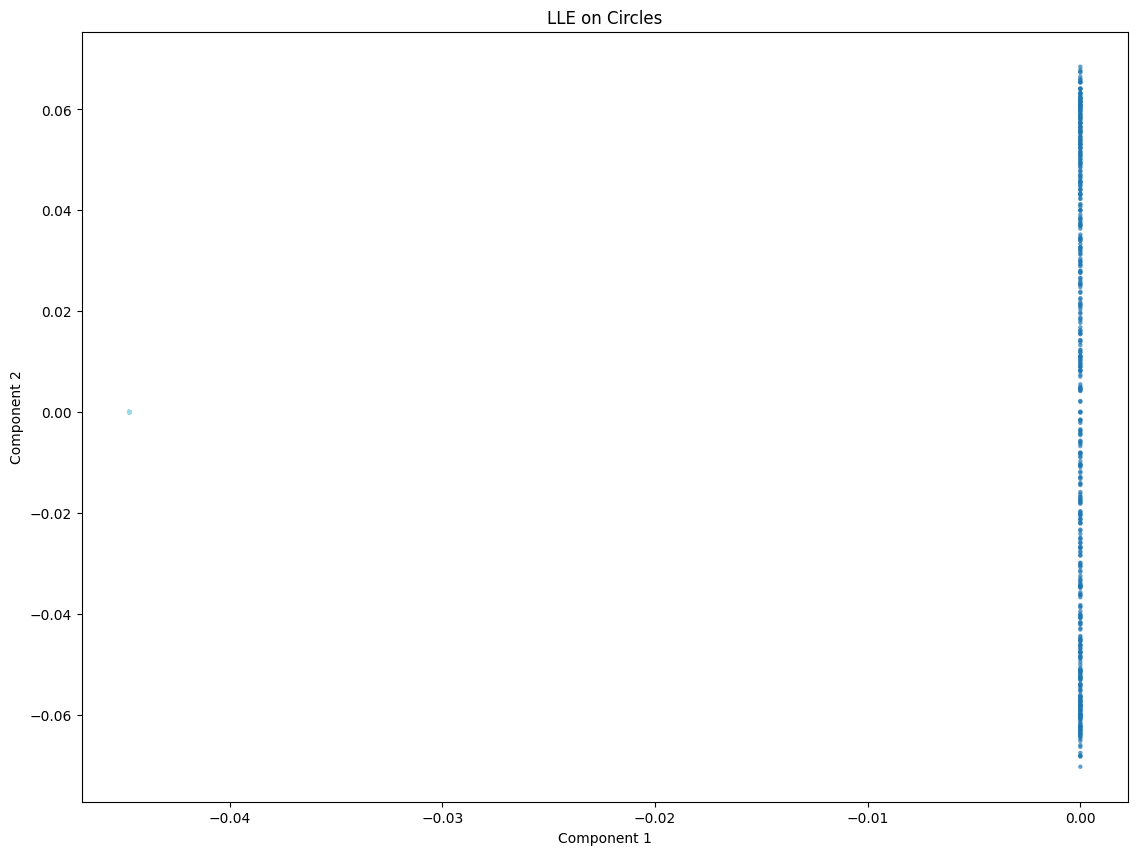

<Axes: title={'center': 'LLE on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [10]:
# Run LLE on circles and plot the 2D embedding colored by label.
circles_X_2d_lle = lle_model.fit_transform(circles_X)
plot_embedding_scatter(circles_X_2d_lle, circles_y, title="LLE on Circles", s=10, alpha=0.7)

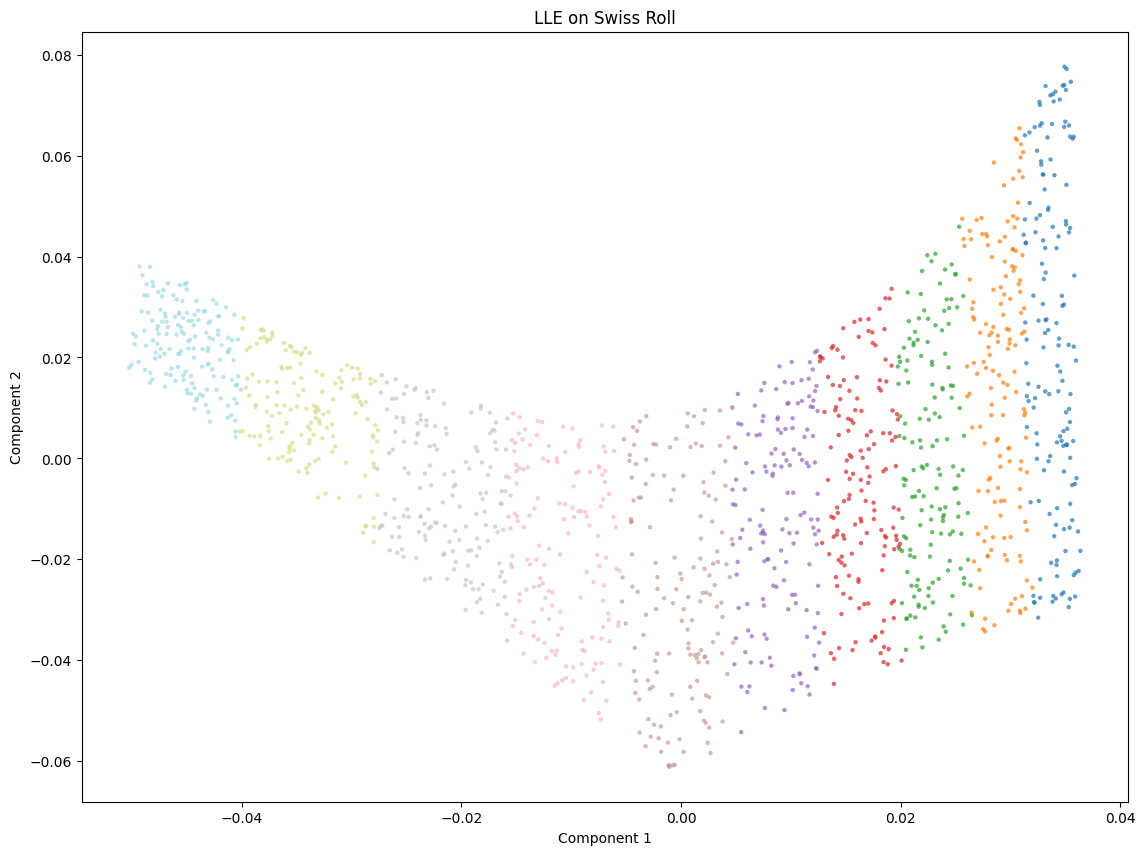

<Axes: title={'center': 'LLE on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [11]:
# Run LLE on swiss roll to test unfolding of the 3D manifold.
swiss_roll_X_2d_lle = lle_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_X_2d_lle, swiss_roll_y, title="LLE on Swiss Roll", s=10, alpha=0.7)

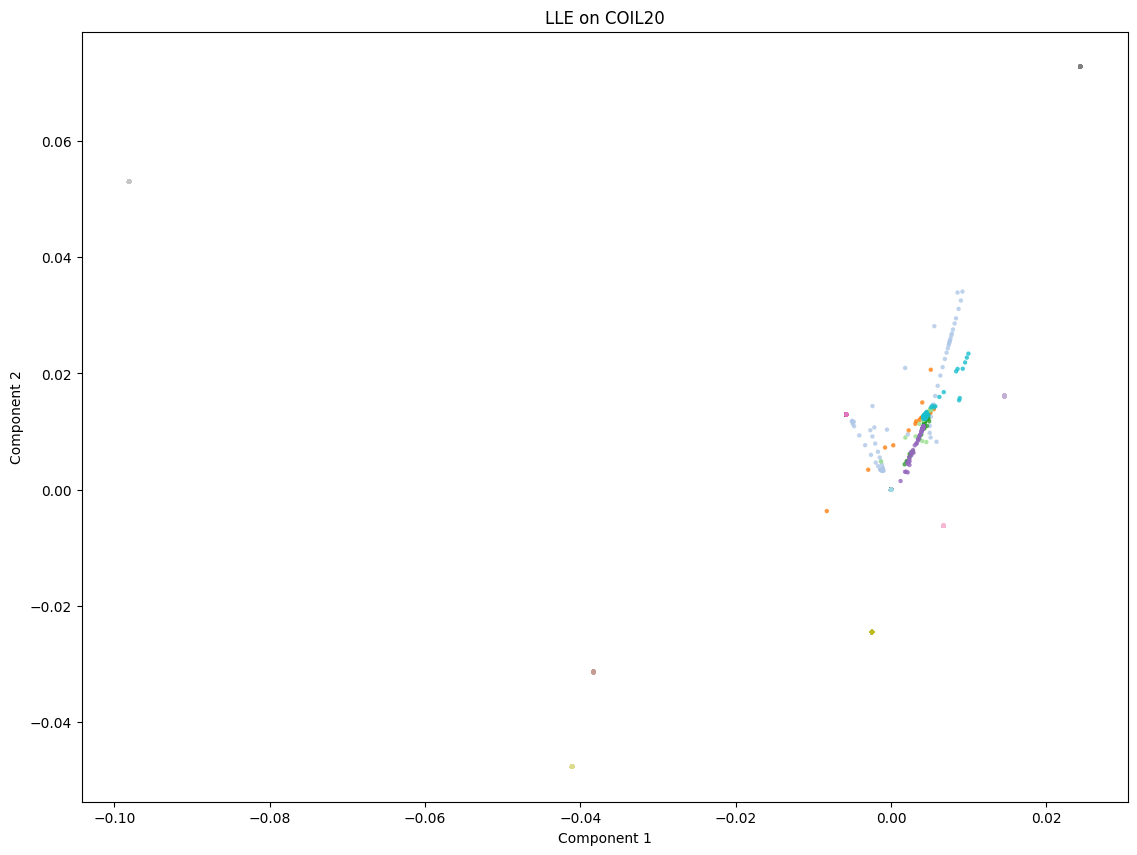

<Axes: title={'center': 'LLE on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [12]:
# Reduce COIL-20 with LLE and inspect class separation.
coil20_X_2d_lle = lle_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_X_2d_lle, coil20_y, title="LLE on COIL20", s=10)

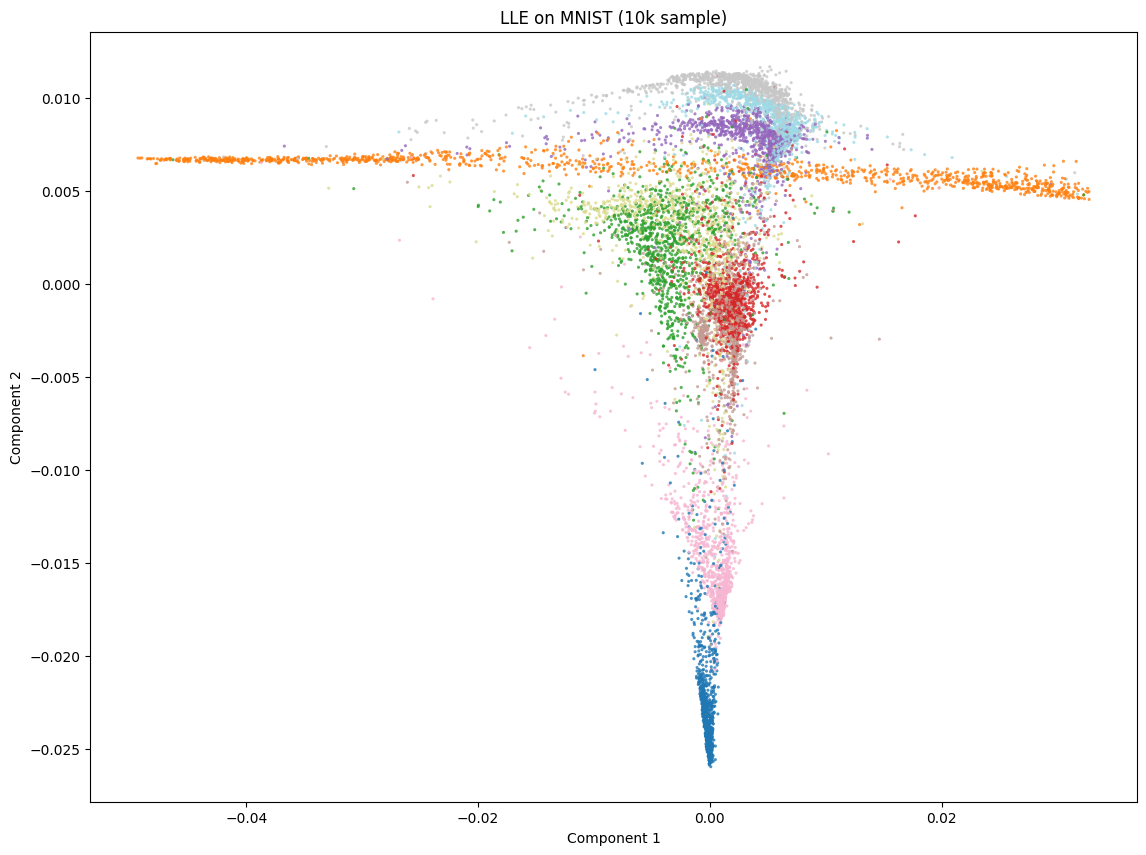

<Axes: title={'center': 'LLE on MNIST (10k sample)'}, xlabel='Component 1', ylabel='Component 2'>

In [13]:
# Run LLE on the 10k MNIST sample to reduce compute cost.
mnist_X_2d_lle = lle_model.fit_transform(mnist_X_sample)
plot_embedding_scatter(mnist_X_2d_lle, mnist_y_sample, title="LLE on MNIST (10k sample)", s=5)

### Nhận xét

- **Circles:** LLE giữ được cấu trúc cục bộ của hai vòng tròn, nhưng embedding 2D có thể làm biến dạng hình dạng tổng thể. Các điểm cùng nhãn vẫn nằm gần nhau tương đối rõ, phù hợp với mục tiêu bảo toàn láng giềng.
- **Swiss roll:** Swiss roll được trải phẳng thành không gian 2D với gradient màu khá liên tục. Một số vùng biên có thể bị cong hoặc nén lại, cho thấy LLE nhạy với cách chọn số láng giềng.
- **COIL-20:** COIL-20 tạo ra một vài cụm theo đối tượng, nhưng các cụm vẫn chồng lấp do ảnh có số chiều lớn và thay đổi theo góc quay. LLE chủ yếu bảo toàn quan hệ cục bộ nên khả năng tách lớp không hoàn toàn rõ ràng.
- **MNIST (10k mẫu):** MNIST sau LLE có các nhóm chữ số tương đối riêng biệt, nhưng nhiều chữ số có nét viết gần nhau vẫn bị lẫn. Kết quả trên mẫu 10k giúp giảm chi phí tính toán, đổi lại có thể mất một phần cấu trúc của toàn bộ tập dữ liệu.


## Laplacian Eigenmaps

In [14]:
# Initialize Laplacian Eigenmaps: k-NN graph and 2D embedding from the Laplacian spectrum.
laplacian_model = LaplacianEigenmaps(
  n_neighbors=15, 
  n_components=2, 
  sigma=5.0
)

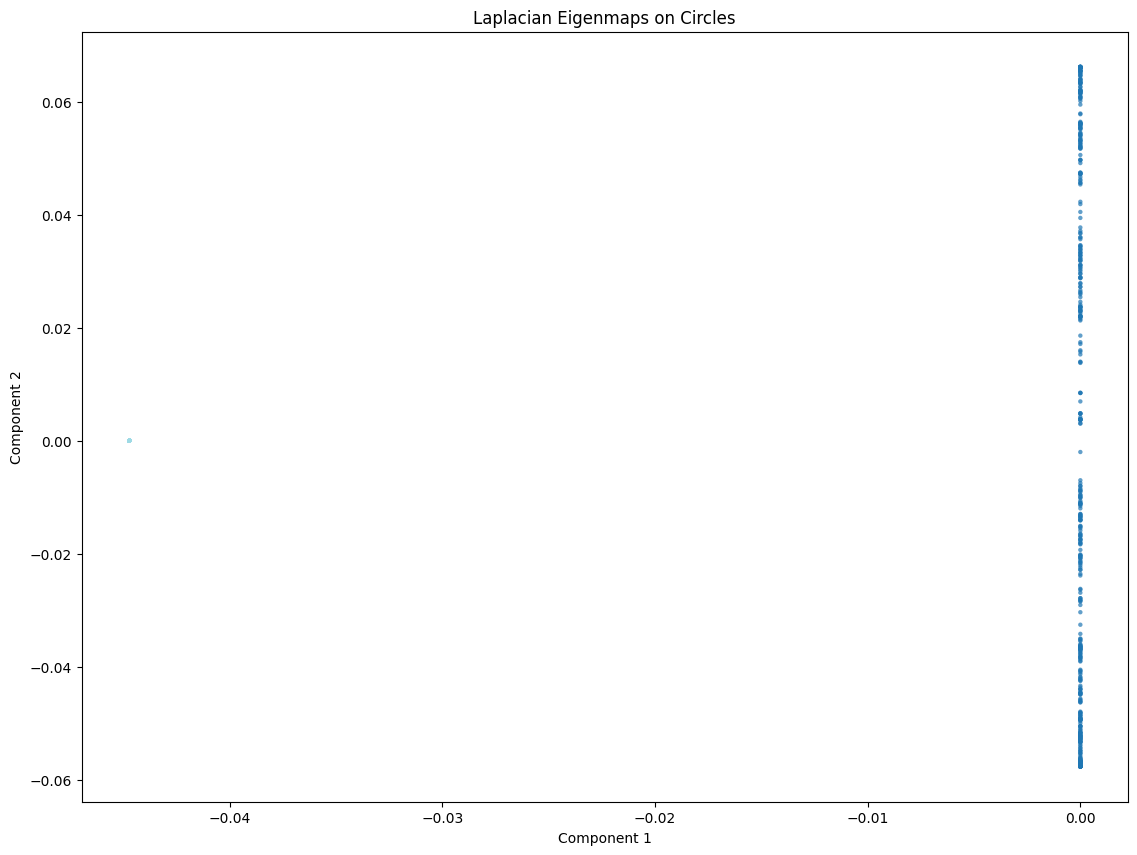

<Axes: title={'center': 'Laplacian Eigenmaps on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [15]:
# Run Laplacian Eigenmaps on circles and visualize the result.
circles_X_2d_le = laplacian_model.fit_transform(circles_X)
plot_embedding_scatter(circles_X_2d_le, circles_y, title="Laplacian Eigenmaps on Circles", s=10, alpha=0.7)

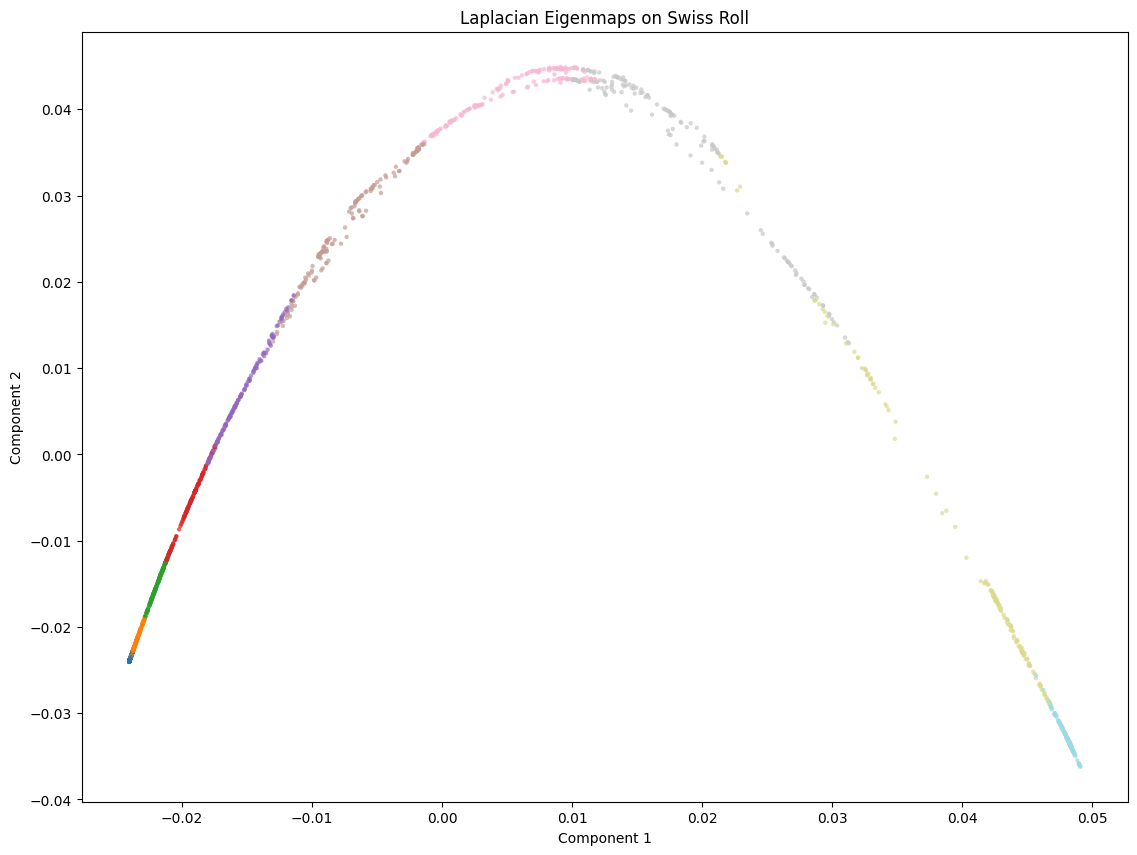

<Axes: title={'center': 'Laplacian Eigenmaps on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [16]:
# Run Laplacian Eigenmaps on swiss roll for comparison with LLE.
swiss_roll_X_2d_le = laplacian_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_X_2d_le, swiss_roll_y, title="Laplacian Eigenmaps on Swiss Roll", s=10, alpha=0.7)

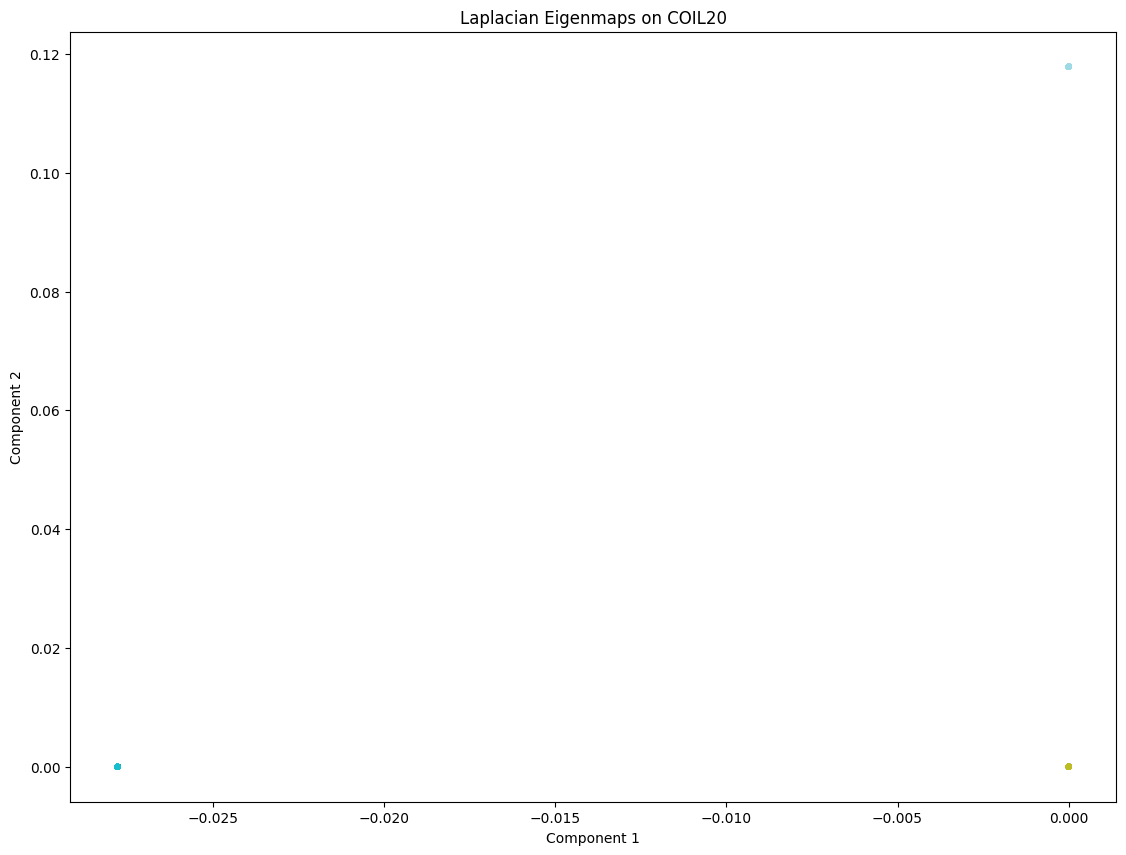

<Axes: title={'center': 'Laplacian Eigenmaps on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [17]:
# Run Laplacian Eigenmaps on flattened COIL-20 images.
coil20_X_2d_le = laplacian_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_X_2d_le, coil20_y, title="Laplacian Eigenmaps on COIL20", s=20, alpha=0.7)

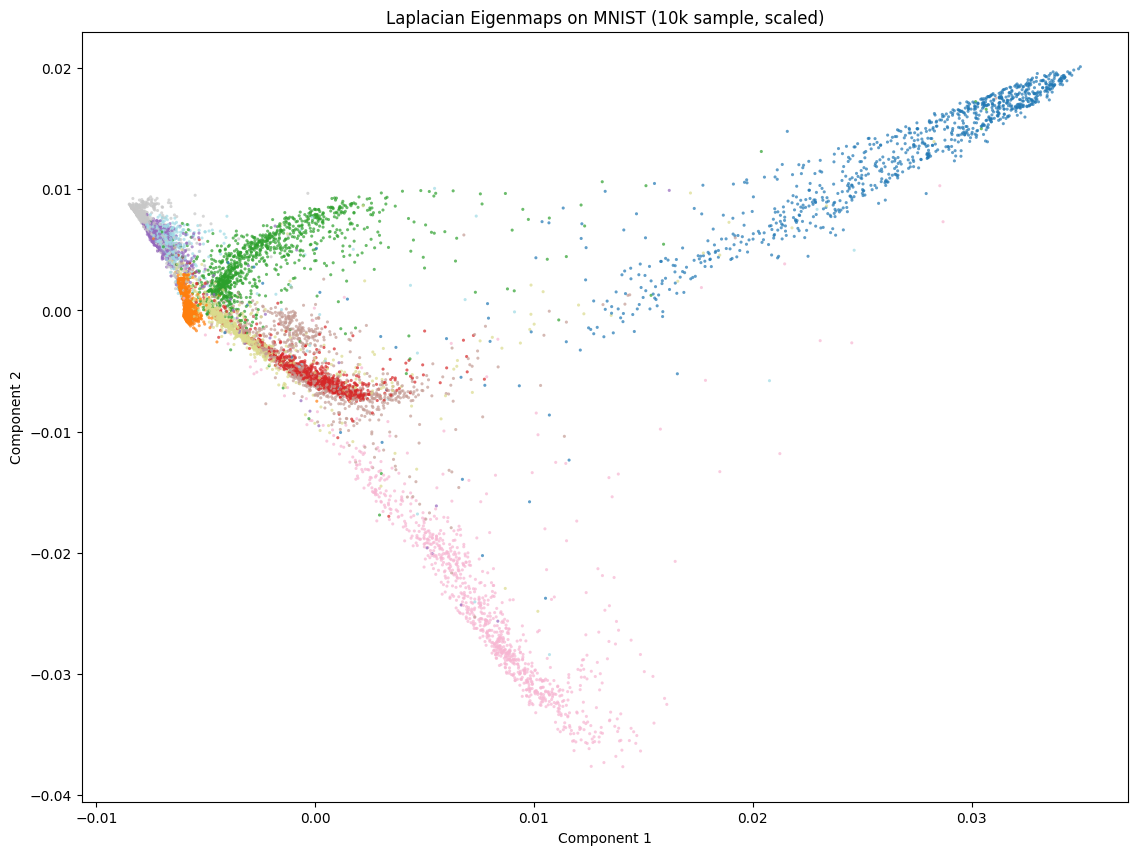

<Axes: title={'center': 'Laplacian Eigenmaps on MNIST (10k sample, scaled)'}, xlabel='Component 1', ylabel='Component 2'>

In [18]:
# Scale MNIST pixels to [0, 1] before distances for Laplacian Eigenmaps.
mnist_X_sample_scaled = mnist_X_sample / 255.0
mnist_X_2d_le = laplacian_model.fit_transform(mnist_X_sample_scaled)
plot_embedding_scatter(mnist_X_2d_le, mnist_y_sample, title="Laplacian Eigenmaps on MNIST (10k sample, scaled)", s=5, alpha=0.7)

### Nhận xét

- **Circles:** Laplacian Eigenmaps biểu diễn dữ liệu dựa trên đồ thị láng giềng, nên các điểm liên thông cục bộ được giữ gần nhau. Với circles, cấu trúc hai vòng có thể hiện rõ nhưng hình dạng tổng thể phụ thuộc mạnh vào đồ thị k-NN.
- **Swiss roll:** Embedding của swiss roll có sự chuyển màu khá mượt, cho thấy quan hệ lân cận trên manifold được bảo toàn. Nếu có vùng bị chồng hoặc bị kéo dài, đó là dấu hiệu tham số láng giềng/sigma ảnh hưởng đến trọng số cạnh của đồ thị.
- **COIL-20:** Trên COIL-20, Laplacian Eigenmaps gom được một số ảnh gần nhau về mặt thị giác, nhưng các lớp đối tượng chưa tách thành các cụm sạch. Điều này dễ xảy ra khi khoảng cách Euclidean trên pixel chưa nắm bắt hết khác biệt ngữ nghĩa giữa đối tượng.
- **MNIST (10k mẫu, scale [0, 1]):** Việc scale pixel về [0, 1] giúp khoảng cách ổn định hơn trước khi lập đồ thị. Các chữ số có xu hướng gom cụm, nhưng những cặp dễ nhầm lẫn như 4/9, 3/5 hoặc 7/9 vẫn có thể nằm gần nhau.


## t-SNE

### Nhận xét

*Chưa có thí nghiệm / plot — bổ sung nhận xét sau khi chạy t-SNE trên các bộ dữ liệu.*


## UMAP

In [19]:
from umap import UMAP

# Initialize UMAP with a fixed seed for more stable embeddings across runs.
umap_model = UMAP(
  n_neighbors=15,
  min_dist=0.1,
  n_components=2,
  metric='euclidean',
  random_state=SEED
)

d:\hcmus\semester-6\introduction-to-machine-learning\csc14005-introduction-to-machine-learning\lab-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


d:\hcmus\semester-6\introduction-to-machine-learning\csc14005-introduction-to-machine-learning\lab-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


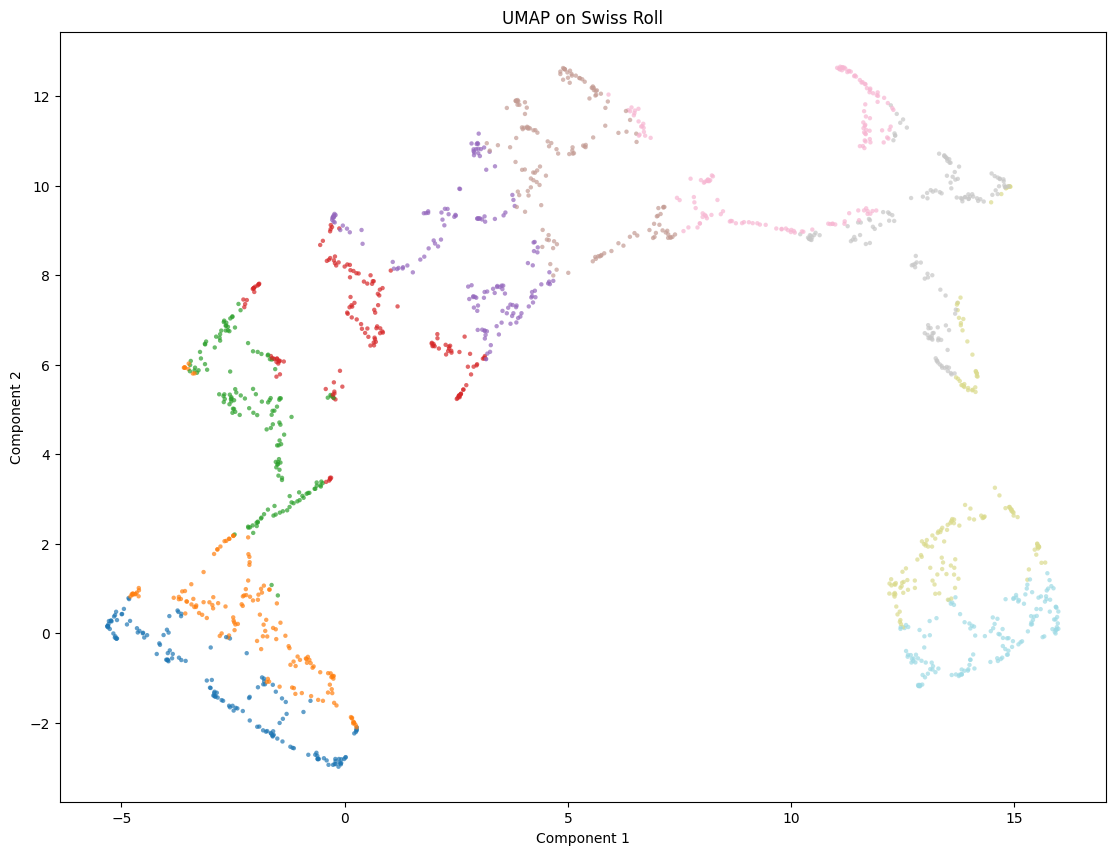

<Axes: title={'center': 'UMAP on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [20]:
# Run UMAP on swiss roll and plot the 2D embedding.
swiss_roll_2d = umap_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_2d, swiss_roll_y, title="UMAP on Swiss Roll", s=10, alpha=0.7)

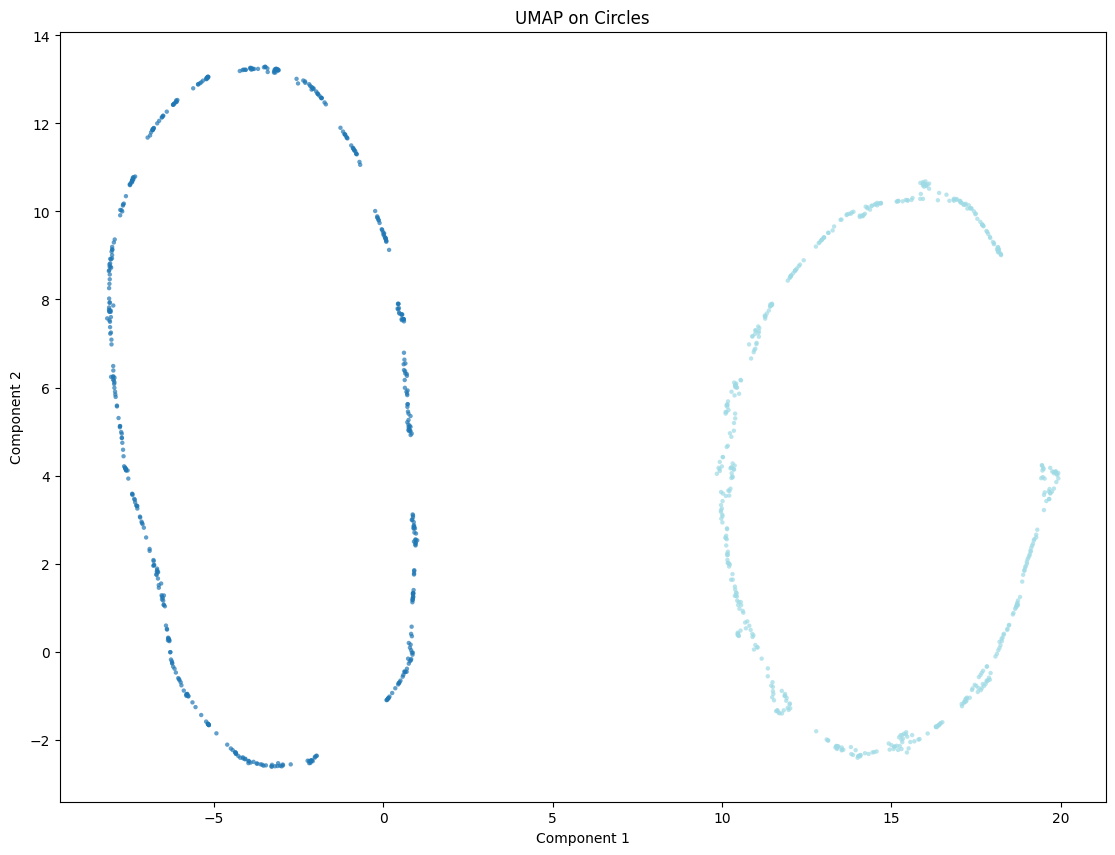

<Axes: title={'center': 'UMAP on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [21]:
# Run UMAP on circles to inspect nonlinear structure preservation.
circles_2d = umap_model.fit_transform(circles_X)
plot_embedding_scatter(circles_2d, circles_y, title="UMAP on Circles", s=10, alpha=0.7)

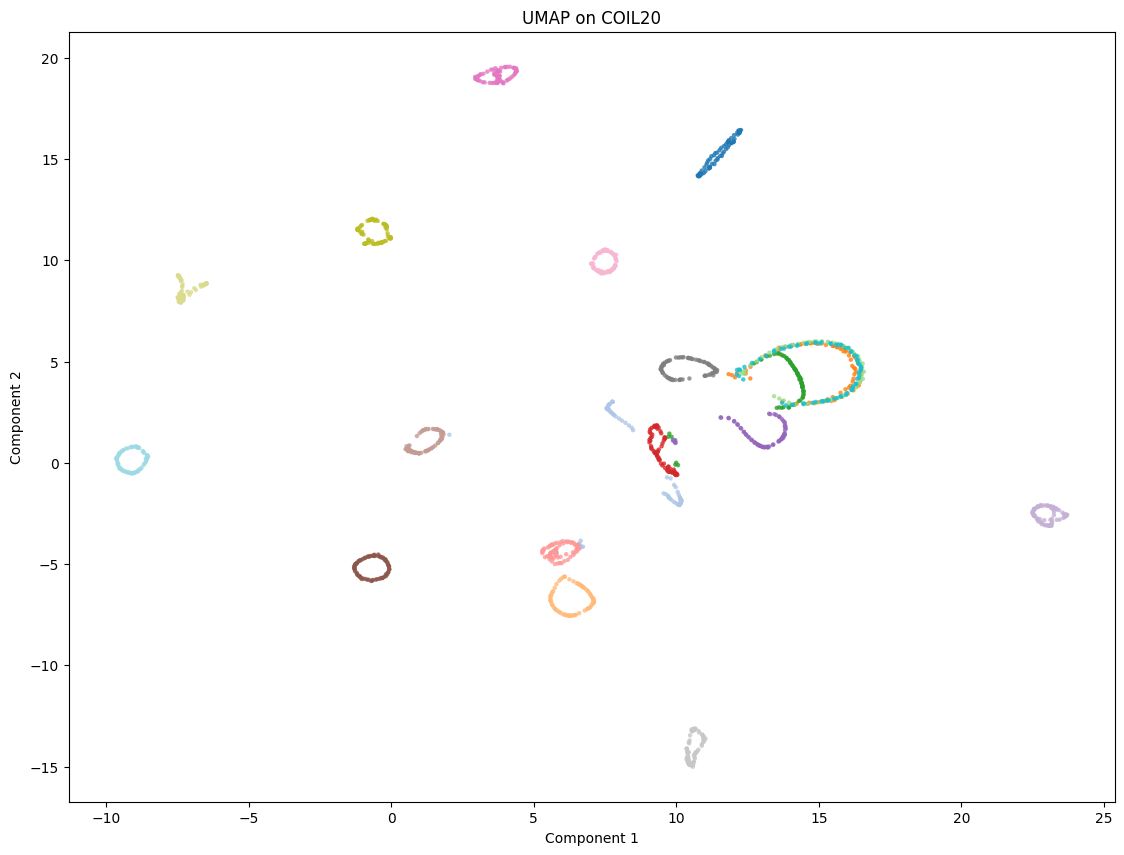

<Axes: title={'center': 'UMAP on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [22]:
# Run UMAP on COIL-20 and color by object label.
coil20_2d = umap_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_2d, coil20_y, title="UMAP on COIL20", s=10)

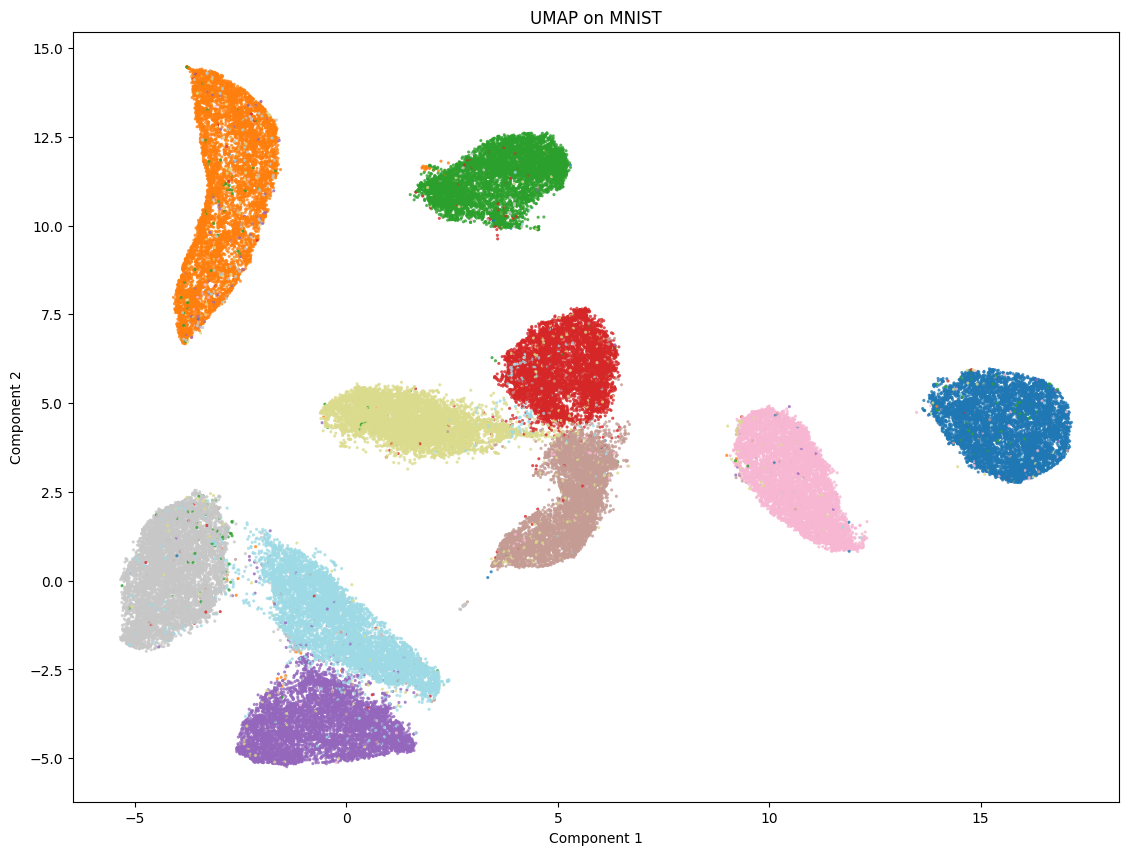

<Axes: title={'center': 'UMAP on MNIST'}, xlabel='Component 1', ylabel='Component 2'>

In [23]:
# Run UMAP on full MNIST to view digit clusters in 2D.
mnist_X_2d = umap_model.fit_transform(mnist_X)
plot_embedding_scatter(mnist_X_2d, mnist_y, title="UMAP on MNIST", s=5)

### Nhận xét

- **Circles:** UMAP tách hai vòng/các nhóm điểm khá rõ trong không gian 2D. So với các phương pháp đồ thị phổ, embedding này dễ nhìn hơn cho mục tiêu trực quan hóa cụm.
- **Swiss roll:** UMAP thường trải swiss roll thành mặt phẳng rõ và liên tục hơn, với các màu thay đổi theo thứ tự manifold. Kết quả cho thấy UMAP bảo toàn được cả cấu trúc cục bộ lẫn một phần cấu trúc toàn cục.
- **COIL-20:** COIL-20 với UMAP tạo các cụm đối tượng rõ hơn, nhưng vẫn có một số cụm gần nhau do các ảnh có góc nhìn liên tiếp hoặc đặc trưng pixel tương tự. UMAP phù hợp cho trực quan hóa dữ liệu ảnh hơn khi cần thấy cấu trúc cụm.
- **MNIST (toàn bộ tập):** UMAP trên MNIST tạo các cụm chữ số khá tách biệt, thể hiện rõ cấu trúc lớp trong dữ liệu. Những chữ số có hình dạng gần nhau vẫn có vùng tiếp giáp hoặc chồng lấp, điều này phản ánh sự tương đồng tự nhiên của chữ viết tay.


# Bảng nhận xét tổng hợp

| Thuật toán | Circles | Swiss roll | COIL-20 | MNIST | Đánh giá chung |
|------------|---------|------------|---------|-------|----------------|
| PCA | — | — | — | — | *(chờ thí nghiệm)* |
| KPCA | — | — | — | — | *(chờ thí nghiệm)* |
| LLE | Giữ cấu trúc cục bộ hai vòng; có thể biến dạng hình tổng thể | Trải phẳng mượt; nhạy số láng giềng ở vùng biên | Vài cụm theo đối tượng nhưng còn chồng lấp | Nhóm chữ số tách tương đối; dễ lẫn nét gần nhau (10k) | Bảo toàn láng giềng cục bộ; tách lớp trung bình trên ảnh/MNIST |
| Laplacian Eigenmaps | Hai vòng thấy được; phụ thuộc đồ thị k-NN | Chuyển màu mượt; tham số ảnh hưởng vùng chồng/kéo | Gom ảnh gần nhau nhưng lớp chưa tách sạch | Gom cụm sau scale; cặp 4/9, 3/5, 7/9 vẫn gần (10k) | Đồ thị láng giềng; tương tự LLE, pixel distance hạn chế trên COIL-20 |
| t-SNE | — | — | — | — | *(chờ thí nghiệm)* |
| UMAP | Tách hai vòng rõ; dễ nhìn cho cụm | Trải phẳng rõ, giữ cả cục bộ và một phần toàn cục | Cụm đối tượng rõ hơn; vẫn có cụm gần nhau | Cụm chữ số tách biệt; chữ tương tự còn tiếp giáp (full) | Trực quan cụm tốt nhất trong các phương pháp đã chạy |
